In [1]:
from pathlib import Path
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:")
print(PROJECT_ROOT)

Project root:
c:\Work\Quantum-Adversarial-Robustness


In [2]:
SEED = 42

NUM_QUBITS = 4

MODEL_PATH = (
    PROJECT_ROOT
    / "results"
    / "models"
    / "vqc_04B_scaled_seed42.pt"
)

SCALER_PATH = (
    PROJECT_ROOT
    / "results"
    / "preprocessing"
    / "standard_scaler_04B_seed42.joblib"
)

DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "binary"
)

print("Model:")
print(MODEL_PATH)

print()

print("Scaler:")
print(SCALER_PATH)

Model:
c:\Work\Quantum-Adversarial-Robustness\results\models\vqc_04B_scaled_seed42.pt

Scaler:
c:\Work\Quantum-Adversarial-Robustness\results\preprocessing\standard_scaler_04B_seed42.joblib


In [3]:
print("Model exists :", MODEL_PATH.exists())
print("Scaler exists:", SCALER_PATH.exists())

assert MODEL_PATH.exists(), (
    f"Missing model checkpoint: {MODEL_PATH}"
)

assert SCALER_PATH.exists(), (
    f"Missing scaler: {SCALER_PATH}"
)

Model exists : True
Scaler exists: True


In [4]:
X_train = np.load(
    DATA_DIR / "X_train.npy"
)

X_test = np.load(
    DATA_DIR / "X_test.npy"
)

y_train = np.load(
    DATA_DIR / "y_train.npy"
)

y_test = np.load(
    DATA_DIR / "y_test.npy"
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (11824, 4)
X_test : (2956, 4)
y_train: (11824,)
y_test : (2956,)


In [5]:
import joblib

scaler = joblib.load(
    SCALER_PATH
)

print(scaler)

StandardScaler()


In [7]:
from sklearn.model_selection import train_test_split

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train,
)

X_test_scaled = scaler.transform(
    X_test
)

print("Scaled test shape:")
print(X_test_scaled.shape)

print()
print("Test feature means:")
print(X_test_scaled.mean(axis=0))

print()
print("Test feature std:")
print(X_test_scaled.std(axis=0))

Scaled test shape:
(2956, 4)

Test feature means:
[0.0017654  0.00180763 0.01846003 0.03138886]

Test feature std:
[1.00099269 1.00601958 0.99919916 0.98443775]


In [8]:
X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
).reshape(-1, 1)

print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

X_test_tensor: torch.Size([2956, 4])
y_test_tensor: torch.Size([2956, 1])


In [9]:
from src.models.quantum_model import create_model
from src.models.hybrid_classifier import HybridClassifier

In [10]:
quantum_model = create_model(
    num_qubits=NUM_QUBITS
)

model = HybridClassifier(
    quantum_model=quantum_model
)

model = model.to("cpu")

print(model)

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


HybridClassifier(
  (quantum): TorchConnector()
  (classifier): Linear(in_features=1, out_features=1, bias=True)
)


In [11]:
state_dict = torch.load(
    MODEL_PATH,
    map_location="cpu"
)

model.load_state_dict(
    state_dict
)

model.eval()

print("Successfully loaded trained 04B model.")

Successfully loaded trained 04B model.


In [12]:
print("=" * 60)
print("TRAINED 04B CLASSIFIER PARAMETERS")
print("=" * 60)

print(
    "Weight:",
    model.classifier.weight.detach().numpy()
)

print(
    "Bias:",
    model.classifier.bias.detach().numpy()
)

TRAINED 04B CLASSIFIER PARAMETERS
Weight: [[2.050361]]
Bias: [0.04361313]


In [13]:
with torch.no_grad():

    quantum_output = model.quantum(
        X_test_tensor
    )

print("Quantum output shape:")
print(quantum_output.shape)

Quantum output shape:
torch.Size([2956, 1])


In [14]:
q = quantum_output.squeeze()

print("=" * 60)
print("QUANTUM OUTPUT STATISTICS")
print("=" * 60)

print(
    f"Min : {q.min().item():.6f}"
)

print(
    f"Max : {q.max().item():.6f}"
)

print(
    f"Mean: {q.mean().item():.6f}"
)

print(
    f"Std : {q.std().item():.6f}"
)

QUANTUM OUTPUT STATISTICS
Min : -0.939856
Max : 0.805809
Mean: 0.029854
Std : 0.199254


In [15]:
y = y_test_tensor.squeeze()

q_class0 = q[y == 0]
q_class1 = q[y == 1]

print("=" * 60)
print("QUANTUM OUTPUT BY CLASS")
print("=" * 60)

print(
    f"Class 0 samples: {len(q_class0)}"
)

print(
    f"Class 0 mean   : {q_class0.mean().item():.6f}"
)

print(
    f"Class 0 std    : {q_class0.std().item():.6f}"
)

print()

print(
    f"Class 1 samples: {len(q_class1)}"
)

print(
    f"Class 1 mean   : {q_class1.mean().item():.6f}"
)

print(
    f"Class 1 std    : {q_class1.std().item():.6f}"
)

QUANTUM OUTPUT BY CLASS
Class 0 samples: 1381
Class 0 mean   : -0.005803
Class 0 std    : 0.239028

Class 1 samples: 1575
Class 1 mean   : 0.061119
Class 1 std    : 0.149499


In [16]:
mean0 = q_class0.mean().item()
mean1 = q_class1.mean().item()

mean_difference = abs(
    mean0 - mean1
)

print("=" * 60)
print("CLASS SEPARATION")
print("=" * 60)

print(f"Class 0 mean: {mean0:.6f}")
print(f"Class 1 mean: {mean1:.6f}")

print(
    f"Absolute mean difference: "
    f"{mean_difference:.6f}"
)

CLASS SEPARATION
Class 0 mean: -0.005803
Class 1 mean: 0.061119
Absolute mean difference: 0.066921


In [17]:
import math

std0 = q_class0.std().item()
std1 = q_class1.std().item()

pooled_std = math.sqrt(
    (std0 ** 2 + std1 ** 2) / 2
)

if pooled_std > 0:

    cohens_d = (
        abs(mean0 - mean1)
        / pooled_std
    )

else:

    cohens_d = 0.0

print("=" * 60)
print("QUANTUM REPRESENTATION EFFECT SIZE")
print("=" * 60)

print(
    f"Pooled standard deviation: "
    f"{pooled_std:.6f}"
)

print(
    f"Cohen's d: {cohens_d:.6f}"
)

QUANTUM REPRESENTATION EFFECT SIZE
Pooled standard deviation: 0.199354
Cohen's d: 0.335689


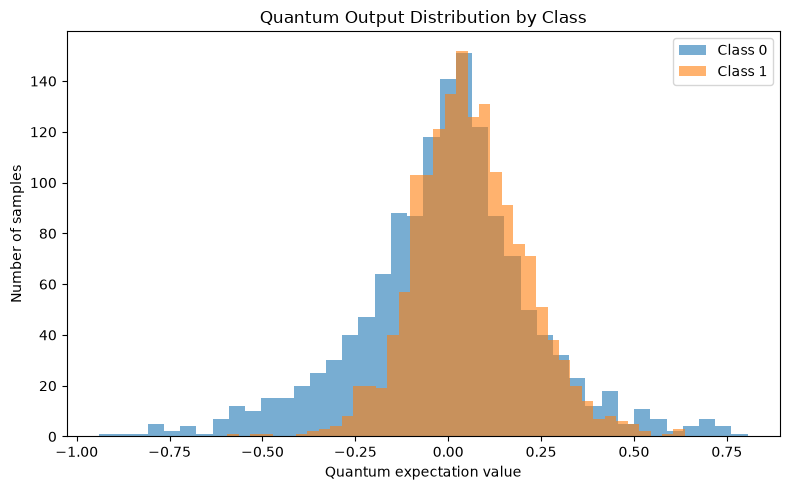

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(
    q_class0.detach().numpy(),
    bins=40,
    alpha=0.6,
    label="Class 0"
)

plt.hist(
    q_class1.detach().numpy(),
    bins=40,
    alpha=0.6,
    label="Class 1"
)

plt.xlabel(
    "Quantum expectation value"
)

plt.ylabel(
    "Number of samples"
)

plt.title(
    "Quantum Output Distribution by Class"
)

plt.legend()

plt.tight_layout()

plt.show()

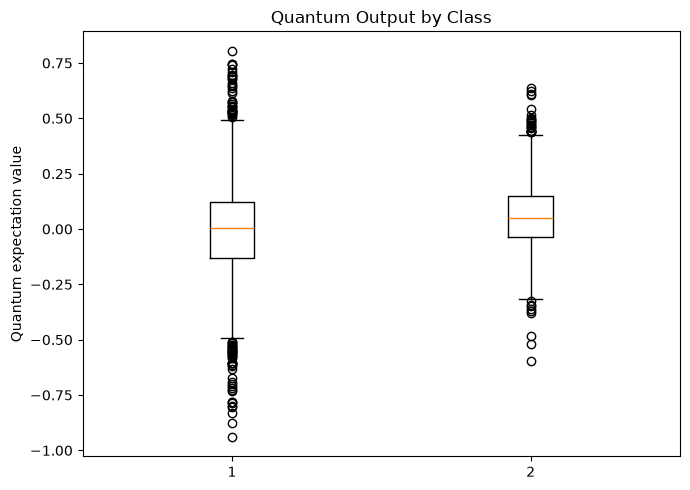

In [20]:
plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        q_class0.detach().numpy(),
        q_class1.detach().numpy()
    ],
    label=[
        "Class 0",
        "Class 1"
    ]
)

plt.ylabel(
    "Quantum expectation value"
)

plt.title(
    "Quantum Output by Class"
)

plt.tight_layout()

plt.show()

In [21]:
with torch.no_grad():

    logits = model(
        X_test_tensor
    )

    probabilities = torch.sigmoid(
        logits
    )

    predictions = (
        probabilities >= 0.5
    ).int()

In [22]:
predictions = predictions.squeeze().int()
y = y_test_tensor.squeeze().int()

print("=" * 60)
print("PREDICTION DISTRIBUTION")
print("=" * 60)

print(
    "Predicted class 0:",
    (predictions == 0).sum().item()
)

print(
    "Predicted class 1:",
    (predictions == 1).sum().item()
)

print()

print(
    "Actual class 0:",
    (y == 0).sum().item()
)

print(
    "Actual class 1:",
    (y == 1).sum().item()
)

PREDICTION DISTRIBUTION
Predicted class 0: 1038
Predicted class 1: 1918

Actual class 0: 1381
Actual class 1: 1575


In [23]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

y_true = y.numpy()
y_pred = predictions.numpy()

cm = confusion_matrix(
    y_true,
    y_pred
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print("=" * 60)
print("04B MODEL — REPRODUCED TEST RESULTS")
print("=" * 60)

print("Confusion matrix:")
print(cm)

print()

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")

04B MODEL — REPRODUCED TEST RESULTS
Confusion matrix:
[[ 597  784]
 [ 441 1134]]

Accuracy : 0.5856
Precision: 0.5912
Recall   : 0.7200
F1       : 0.6493


In [24]:
import json

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "analysis"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

analysis_results = {

    "experiment": "04C",

    "base_model": "04B",

    "seed": SEED,

    "num_qubits": NUM_QUBITS,

    "quantum_output": {

        "min": float(q.min().item()),

        "max": float(q.max().item()),

        "mean": float(q.mean().item()),

        "std": float(q.std().item()),
    },

    "class_0": {

        "samples": int(len(q_class0)),

        "mean": float(
            q_class0.mean().item()
        ),

        "std": float(
            q_class0.std().item()
        ),
    },

    "class_1": {

        "samples": int(len(q_class1)),

        "mean": float(
            q_class1.mean().item()
        ),

        "std": float(
            q_class1.std().item()
        ),
    },

    "mean_difference": float(
        mean_difference
    ),

    "cohens_d": float(
        cohens_d
    ),

    "classification": {

        "accuracy": float(
            accuracy
        ),

        "precision": float(
            precision
        ),

        "recall": float(
            recall
        ),

        "f1": float(
            f1
        ),
    }
}

RESULT_PATH = (
    RESULTS_DIR
    / "04C_quantum_output_analysis_seed42.json"
)

with open(
    RESULT_PATH,
    "w"
) as f:

    json.dump(
        analysis_results,
        f,
        indent=4
    )

print("Saved:")
print(RESULT_PATH)

Saved:
c:\Work\Quantum-Adversarial-Robustness\results\analysis\04C_quantum_output_analysis_seed42.json
